In [5]:
from dask.distributed import LocalCluster, Client
cluster = LocalCluster()
client = Client(cluster)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 16
Total threads: 128,Total memory: 0.98 TiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40967,Workers: 16
Dashboard: http://127.0.0.1:8787/status,Total threads: 128
Started: Just now,Total memory: 0.98 TiB
Comm: tcp://127.0.0.1:37471,Total threads: 8
Dashboard: http://127.0.0.1:37551/status,Memory: 62.93 GiB
Nanny: tcp://127.0.0.1:42045,


In [129]:
iter = 14
foldername = '/home/edavenport/analysis/TPOSE6_VelocityAssim/sep2012/fit_to_obs/vel_withhold_iter' + str(iter) + '/'

### Load MITgcm

In [130]:
## Read in ITER 0 Diagnostics 
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import xarray as xr
from xmitgcm import open_mdsdataset
import numpy as np
import xarray as xr

data_dir = '/data/SO3/edavenport/tpose6/sep2012/velocity_withhold/run_iter14/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

num_diags = 122 #
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags+1,itPerFile)

prefix = ['diag_state','diag_surf']
ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)
ds['XC'] = ds.XC.astype(float)
ds['YC'] = ds.YC.astype(float)
ds['Z'] = ds.Z.astype(float)
ds['XG'] = ds.XG.astype(float)
ds['YG'] = ds.YG.astype(float)

### Load SST Data (oisst)

In [131]:
OISST_filename = '/data/SO6/TPOSE/constraints/sst/mw_fusion_tpose6_2012'

# Read the binary file (big-endian float32)
with open(OISST_filename, 'rb') as f:
    OISST = np.fromfile(f, dtype='>f4')

# Define dimensions
nx, ny, nt = len(ds.XC), len(ds.YC), 366

# Reshape (Fortran order to match MATLAB)
OISST = OISST.reshape((nx, ny, nt), order='F')
OISST = OISST.transpose(1,0,2)

# Convert to xarray DataArray
OISST_da = xr.DataArray(
    OISST[:,:,-len(ds.time):],  # Align time dimension
    dims=['YC', 'XC', 'time'],
    coords={'YC': ds.YC, 'XC': ds.XC, 'time': ds.time},
    name='OISST'
)

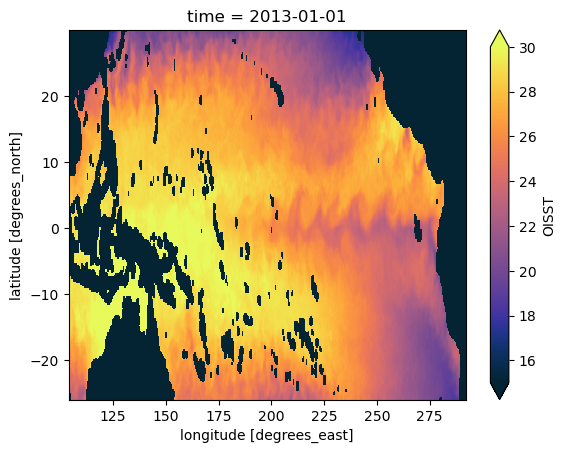

In [132]:
OISST_da.isel(time=-1).plot(vmin=15,vmax=30,cmap=cmo.thermal)

### SST - MITgcm difference

In [133]:
rms_sst = np.sqrt(((ds.THETA.isel(Z=0).compute() - OISST_da)**2).mean(dim='time')).compute()
rms_sst_1 = np.sqrt(((ds.THETA.isel(Z=0).isel(time=slice(0,62)).compute() - OISST_da.isel(time=slice(0,62)))**2).mean(dim='time')).compute()
rms_sst_2 = np.sqrt(((ds.THETA.isel(Z=0).isel(time=slice(62,None)).compute() - OISST_da.isel(time=slice(62,None)))**2).mean(dim='time')).compute()

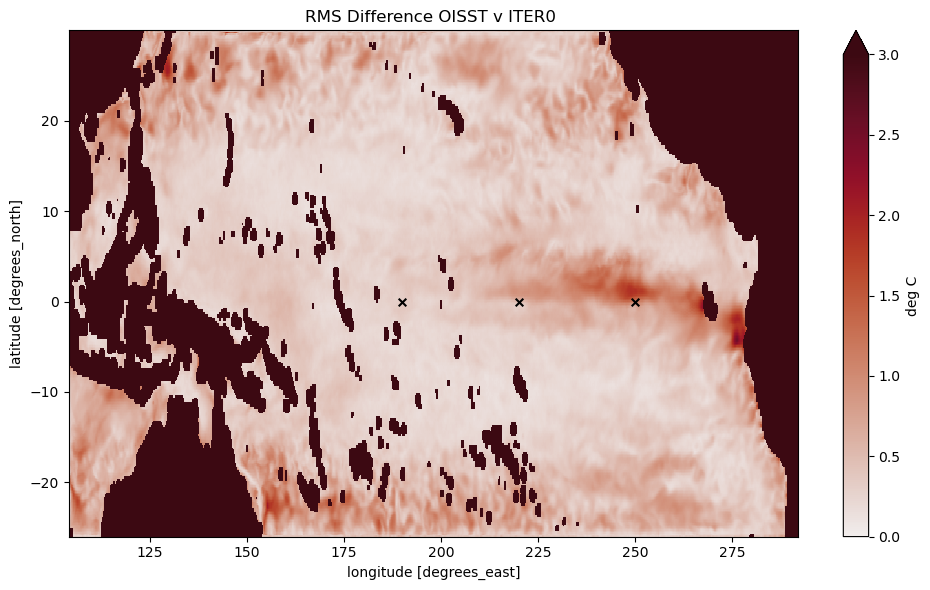

In [126]:
TAO_lon = np.array([190.0, 220.0, 250.0])
TAO_lat = np.array([0.0, 0.0, 0.0])

fig, ax = plt.subplots(figsize=(10,6))
rms_sst.plot(ax=ax,vmin=0,vmax=3,cmap=cmo.amp,cbar_kwargs={'label':'deg C'})
ax.scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax.set_title('RMS Difference OISST v ITER' + str(iter) + ' ')
plt.tight_layout()
fig.savefig(foldername + 'RMS_OISST_vs_Iter' + str(iter) + '.png')

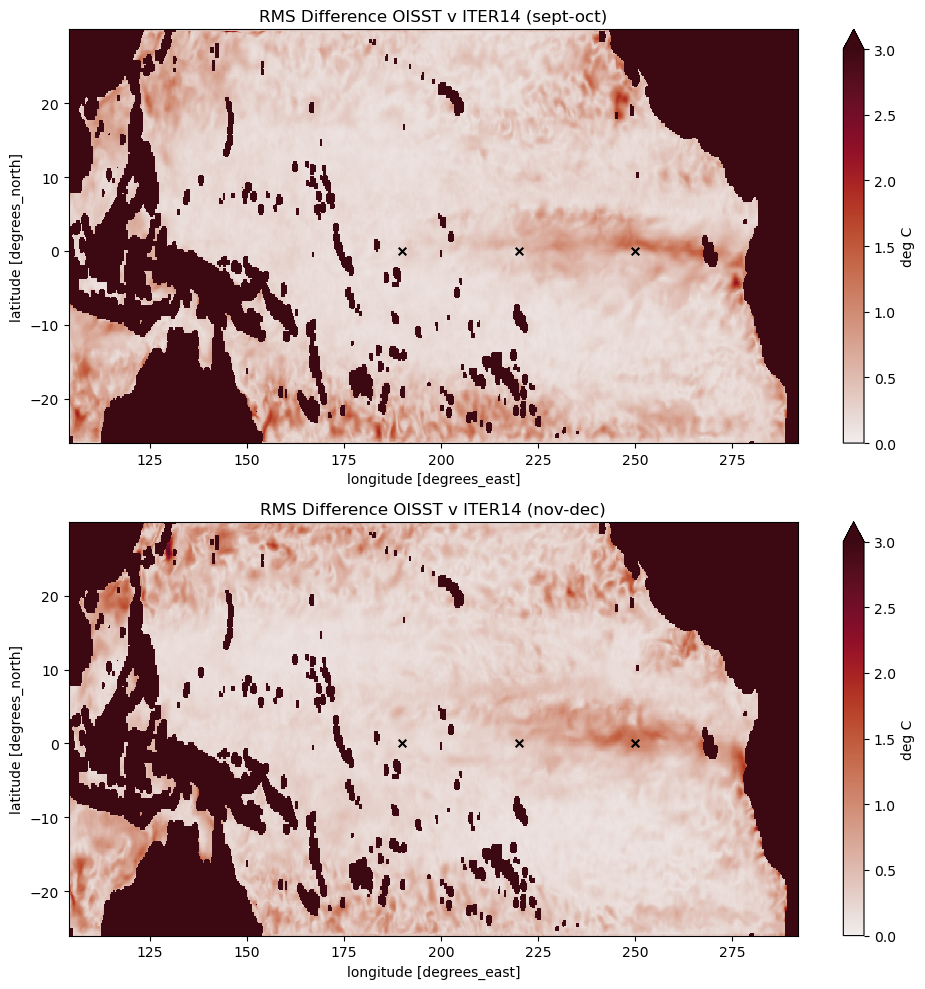

In [134]:
TAO_lon = np.array([190.0, 220.0, 250.0])
TAO_lat = np.array([0.0, 0.0, 0.0])

fig, ax = plt.subplots(figsize=(10,10),nrows=2)
rms_sst_1.plot(ax=ax[0],vmin=0,vmax=3,cmap=cmo.amp,cbar_kwargs={'label':'deg C'})
ax[0].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[0].set_title('RMS Difference OISST v ITER' + str(iter) + ' (sept-oct)')

rms_sst_2.plot(ax=ax[1],vmin=0,vmax=3,cmap=cmo.amp,cbar_kwargs={'label':'deg C'})
ax[1].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[1].set_title('RMS Difference OISST v ITER' + str(iter) + ' (nov-dec)')
plt.tight_layout()
fig.savefig(foldername + 'RMS_OISST_vs_Iter' + str(iter) + '_split.png')

### Load SSH Data (rads)

In [111]:
#rads_ja_tpose6_QC and rads_c2_tpose6_QC
rads_ja_filename = '/data/SO6/TPOSE/constraints/rads/rads_ja_tpose6_QC_2012'
rads_c2_filename = '/data/SO6/TPOSE/constraints/rads/rads_c2_tpose6_QC_2012'

# Read the binary file (big-endian float32)
with open(rads_ja_filename, 'rb') as f:
    rads_ja = np.fromfile(f, dtype='>f4')

# Define dimensions
nx, ny, nt = len(ds.XC), len(ds.YC), 366

# Reshape (Fortran order to match MATLAB)
rads_ja = rads_ja.reshape((nx, ny, nt), order='F')
rads_ja = rads_ja.transpose(1,0,2)

# Convert to xarray DataArray
rads_ja_da = xr.DataArray(
    rads_ja[:,:,-len(ds.time):]/100,  # Align time dimension
    dims=['YC', 'XC', 'time'],
    coords={'YC': ds.YC, 'XC': ds.XC, 'time': ds.time},
    name='rads_ja'
)

# Read the binary file (big-endian float32)
with open(rads_c2_filename, 'rb') as f:
    rads_c2 = np.fromfile(f, dtype='>f4')

# Define dimensions
nx, ny, nt = len(ds.XC), len(ds.YC), 366

# Reshape (Fortran order to match MATLAB)
rads_c2 = rads_c2.reshape((nx, ny, nt), order='F')
rads_c2 = rads_c2.transpose(1,0,2)

# Convert to xarray DataArray
rads_c2_da = xr.DataArray(
    rads_c2[:,:,-len(ds.time):]/100,  # Align time dimension, convert from cm to m
    dims=['YC', 'XC', 'time'],
    coords={'YC': ds.YC, 'XC': ds.XC, 'time': ds.time},
    name='rads_c2'
)

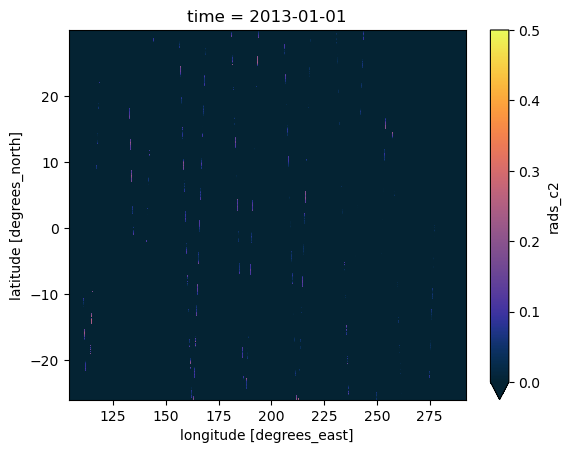

In [112]:
rads_c2_da.isel(time=-1).plot(vmin=0,vmax=0.5,cmap=cmo.thermal)

In [113]:
# replace all -9999 with nan
rads_ja_da = rads_ja_da.where(rads_ja_da != -99.99,other=np.nan)
rads_c2_da = rads_c2_da.where(rads_c2_da != -99.99,other=np.nan)

rms_rads_ja = np.sqrt(((ds.ETAN.compute() - rads_ja_da)**2).mean(dim='time')).compute()
rms_rads_c2 = np.sqrt(((ds.ETAN.compute() - rads_c2_da)**2).mean(dim='time')).compute()

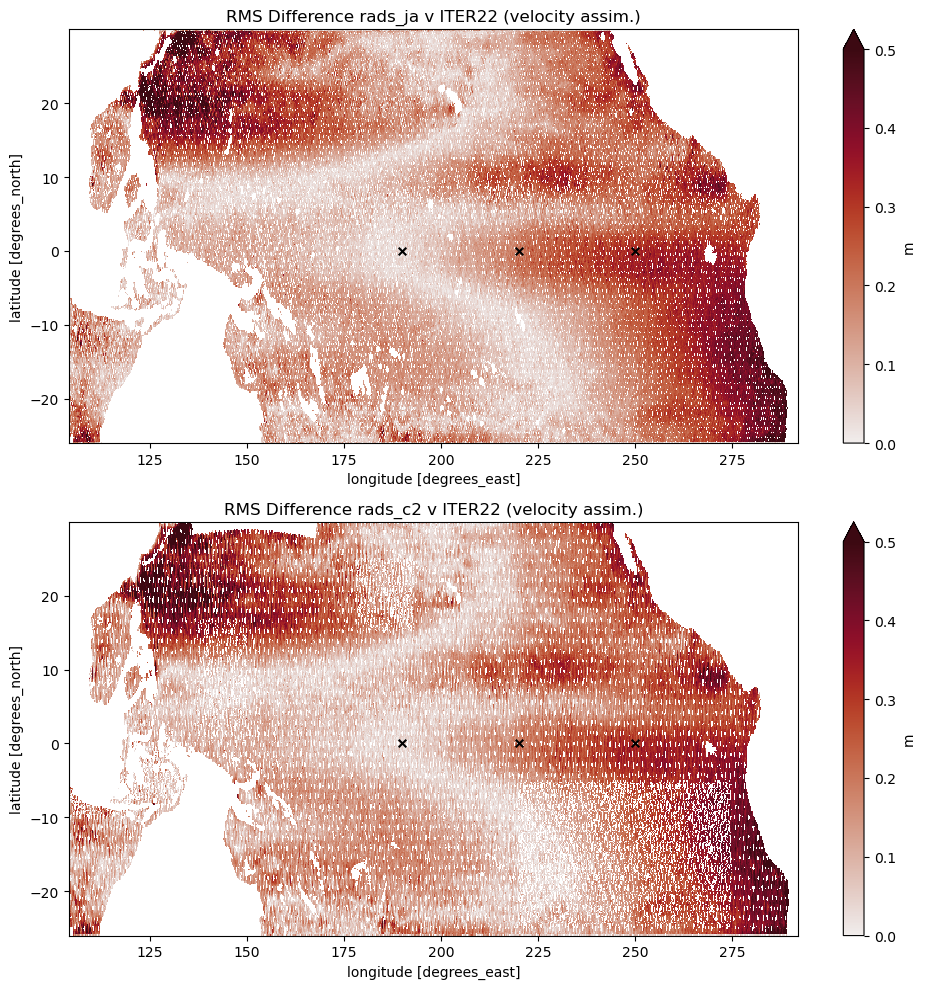

In [114]:
fig, ax = plt.subplots(figsize=(10,10), nrows=2)
rms_rads_ja.plot(ax=ax[0],vmin=0,vmax=0.5,cmap=cmo.amp,cbar_kwargs={'label':'m'})
ax[0].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[0].set_title('RMS Difference rads_ja v ITER' + str(iter) + ' (velocity assim.)')

rms_rads_c2.plot(ax=ax[1],vmin=0,vmax=0.5,cmap=cmo.amp,cbar_kwargs={'label':'m'})
ax[1].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[1].set_title('RMS Difference rads_c2 v ITER' + str(iter) + ' (velocity assim.)')

plt.tight_layout()
fig.savefig(foldername + 'RMS_rads_vs_Iter' + str(iter) + '.png')

### Compare fit over first versus second half of the window

In [115]:
rms_rads_ja_1 = np.sqrt(((ds.ETAN.isel(time=slice(0,62)).compute() - rads_ja_da.isel(time=slice(0,62)))**2).mean(dim='time')).compute()
rms_rads_c2_1 = np.sqrt(((ds.ETAN.isel(time=slice(0,62)).compute() - rads_c2_da.isel(time=slice(0,62)))**2).mean(dim='time')).compute()

rms_rads_ja_2 = np.sqrt(((ds.ETAN.isel(time=slice(62,None)).compute() - rads_ja_da.isel(time=slice(62,None)))**2).mean(dim='time')).compute()
rms_rads_c2_2 = np.sqrt(((ds.ETAN.isel(time=slice(62,None)).compute() - rads_c2_da.isel(time=slice(62,None)))**2).mean(dim='time')).compute()

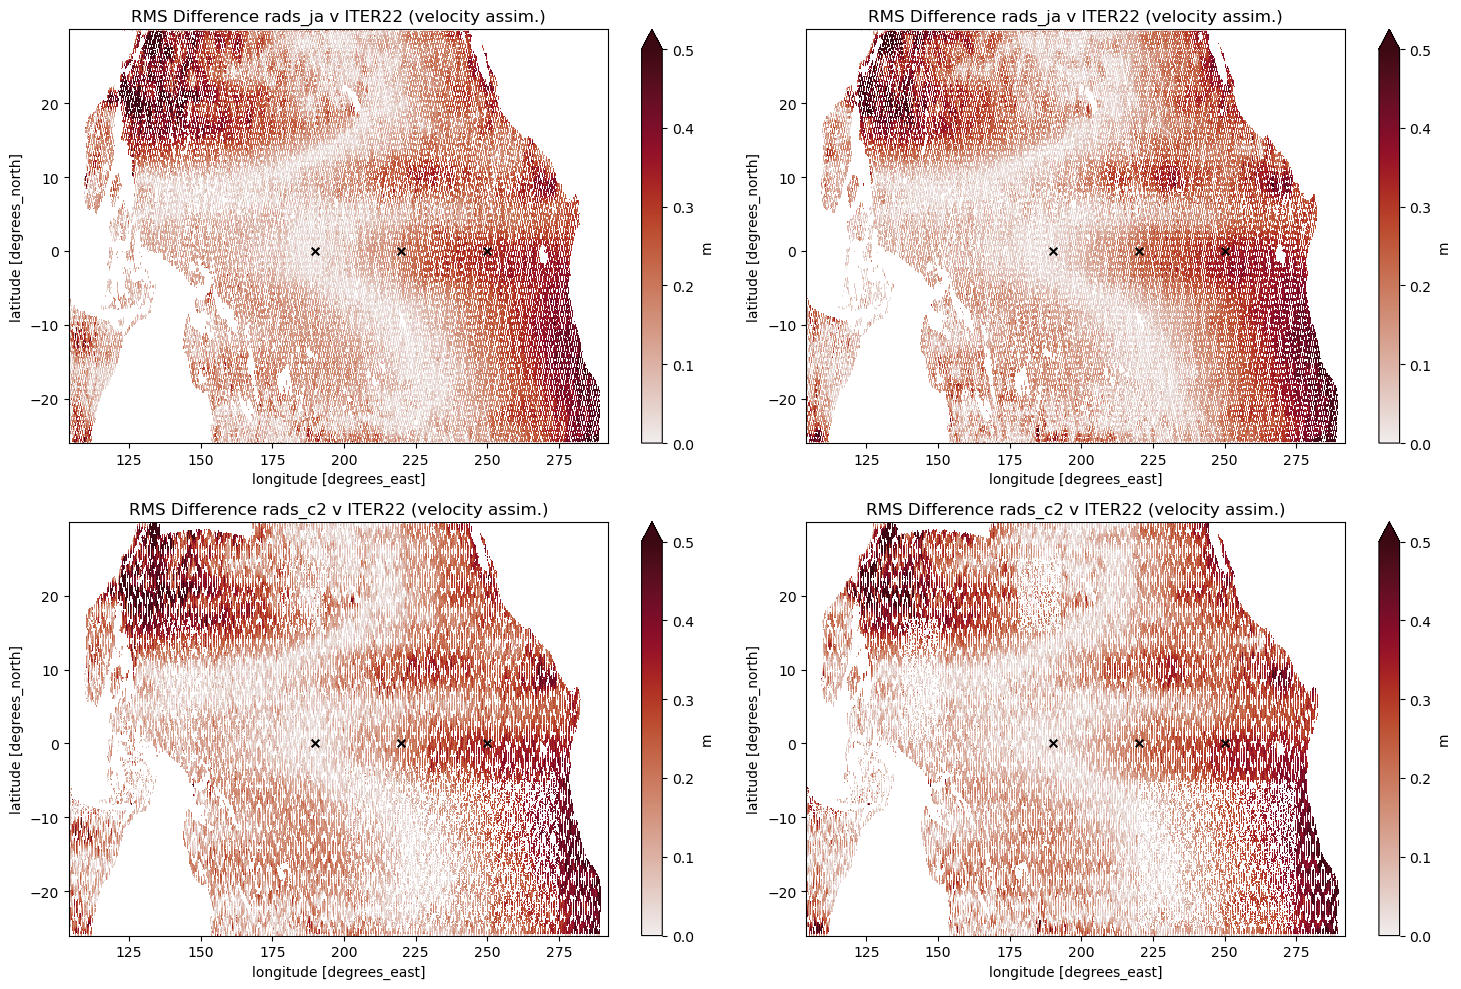

In [117]:
fig, ax = plt.subplots(figsize=(15,10), nrows=2, ncols=2)
rms_rads_ja_1.plot(ax=ax[0,0],vmin=0,vmax=0.5,cmap=cmo.amp,cbar_kwargs={'label':'m'})
ax[0,0].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[0,0].set_title('RMS Difference rads_ja v ITER' + str(iter) + ' (velocity assim.)')

rms_rads_c2_1.plot(ax=ax[1,0],vmin=0,vmax=0.5,cmap=cmo.amp,cbar_kwargs={'label':'m'})
ax[1,0].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[1,0].set_title('RMS Difference rads_c2 v ITER' + str(iter) + ' (velocity assim.)')

rms_rads_ja_2.plot(ax=ax[0,1],vmin=0,vmax=0.5,cmap=cmo.amp,cbar_kwargs={'label':'m'})
ax[0,1].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[0,1].set_title('RMS Difference rads_ja v ITER' + str(iter) + ' (velocity assim.)')

rms_rads_c2_2.plot(ax=ax[1,1],vmin=0,vmax=0.5,cmap=cmo.amp,cbar_kwargs={'label':'m'})
ax[1,1].scatter(TAO_lon,TAO_lat,s=30,c='k',marker='x') # TAO location
ax[1,1].set_title('RMS Difference rads_c2 v ITER' + str(iter) + ' (velocity assim.)')

plt.tight_layout()
fig.savefig(foldername + 'RMS_rads_vs_Iter' + str(iter) + '_split.png')

In [ ]:
client.shutdown()
cluster.close()
client.close()